## NASA C-MAPSS
## Project: AI-Based Remaining Useful Life Estimation
## Dataset: CMAPSS FD001

## **EDA and Cleaning**

#### `Imports`

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import joblib
import json

plt.style.use('seaborn-v0_8')

#### `Load Data`

In [2]:
columns = ['unit', 'cycle'] + \
          ['op_setting_1', 'op_setting_2', 'op_setting_3'] + \
          [f'sensor_{i}' for i in range(1, 22)]
          
path = os.path.join('..', 'Dataset', 'train_FD001.txt')

df = pd.read_csv(path, 
                 sep=' ', 
                 header=None)

df = df.iloc[:, :26]   # remove empty columns
df.columns = columns

df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


In [3]:
df.shape

(20631, 26)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
unit,20631.0,51.506568,2.922763e+01,1.0000,26.0000,52.0000,77.0000,100.0000
cycle,20631.0,108.807862,6.888099e+01,1.0000,52.0000,104.0000,156.0000,362.0000
op_setting_1,20631.0,-0.000009,2.187313e-03,-0.0087,-0.0015,0.0000,0.0015,0.0087
op_setting_2,20631.0,0.000002,2.930621e-04,-0.0006,-0.0002,0.0000,0.0003,0.0006
op_setting_3,20631.0,100.000000,0.000000e+00,100.0000,100.0000,100.0000,100.0000,100.0000
sensor_1,20631.0,518.670000,6.537152e-11,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,3.394700e-12,14.6200,14.6200,14.6200,14.6200,14.6200


In [6]:
df['unit'].nunique()

100

In [7]:
# max cycle for each unit 
max_cycle = df.groupby('unit')['cycle'].max()
max_cycle.head()

unit
1    192
2    287
3    179
4    189
5    269
Name: cycle, dtype: int64

In [8]:
# compute RUL for each row (max cycle for the unit - current cycle)
df['RUL'] = df.apply(lambda row: 
                     max_cycle[row['unit']] - row['cycle'], 
                     axis=1)

In [9]:
df[['unit','cycle','RUL']].head(10)

,unit,cycle,RUL
0,1,1,191.0
1,1,2,190.0
2,1,3,189.0
3,1,4,188.0
4,1,5,187.0
5,1,6,186.0
6,1,7,185.0
7,1,8,184.0
8,1,9,183.0
9,1,10,182.0


In [10]:
# descending order of lifetime
max_cycle.sort_values(ascending=False).head(20)

unit
69    362
92    341
96    336
67    313
83    293
2     287
64    283
95    283
86    278
17    276
56    275
5     269
84    267
7     259
94    258
54    257
46    256
11    240
81    240
20    234
Name: cycle, dtype: int64

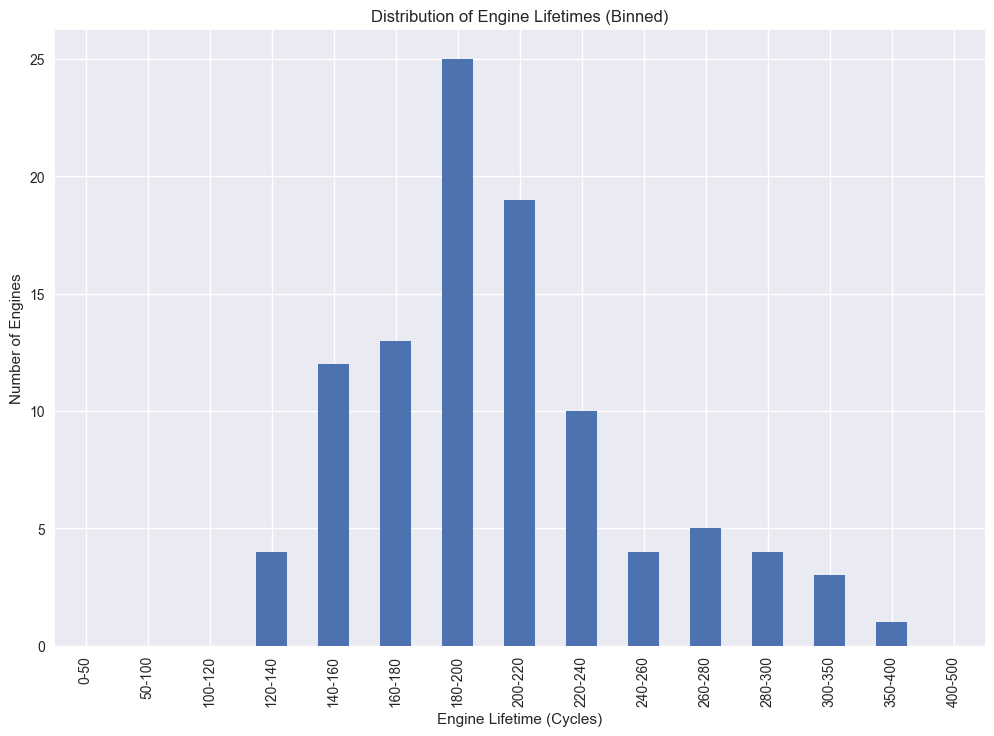

In [11]:
# discretize lifetime

bins = [0, 50, 100, 120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 350, 400, 500]

labels = [f'{bins[i]}-{bins[i+1]}' for i in range(len(bins)-1)]
max_cycle_binned = pd.cut(max_cycle, bins=bins, labels=labels)
max_cycle_binned.value_counts().sort_index().plot(kind='bar', figsize=(12,8))

plt.xlabel("Engine Lifetime (Cycles)")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes (Binned)");

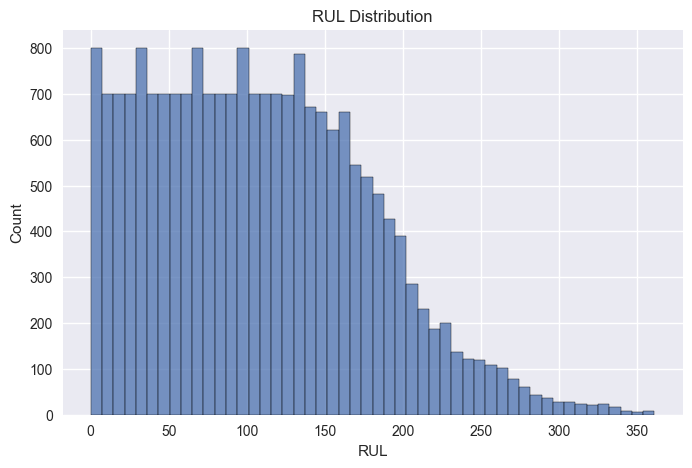

In [12]:
# RUL distribution at the end of the dataset (when cycle = max_cycle)
plt.figure(figsize=(8,5))
sns.histplot(df['RUL'], bins=50)
plt.title("RUL Distribution")
plt.show()

### drop useless sensors

- based on variance in sensor readings

In [13]:
sensor_cols = [col for col in df.columns if 'sensor' in col]

sensor_variance = df[sensor_cols].var().sort_values()

sensor_variance.round(3)

sensor_19      0.000
sensor_18      0.000
sensor_16      0.000
sensor_10      0.000
sensor_5       0.000
sensor_1       0.000
sensor_6       0.000
sensor_15      0.001
sensor_8       0.005
sensor_13      0.005
sensor_21      0.012
sensor_20      0.033
sensor_11      0.071
sensor_2       0.250
sensor_12      0.544
sensor_7       0.783
sensor_17      2.399
sensor_3      37.591
sensor_4      81.011
sensor_14    363.900
sensor_9     487.654
dtype: float64

In [14]:
#drop: sensor_1, sensor_5, sensor_6, sensor_10, sensor_15, sensor_16, sensor_18, sensor_19
df = df.drop(columns=['sensor_1', 'sensor_5', 'sensor_6', 'sensor_10', 'sensor_15', 'sensor_16', 'sensor_18', 'sensor_19'])
df.head()

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,392,39.06,23.4190,191.0
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,392,39.00,23.4236,190.0
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,390,38.95,23.3442,189.0
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,392,38.88,23.3739,188.0
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,393,38.90,23.4044,187.0


In [15]:
sensor_cols = [col for col in df.columns if 'sensor' in col]

In [16]:
df.shape

(20631, 19)

### Clip RUL
- at high RUL no variations in sensor readings 

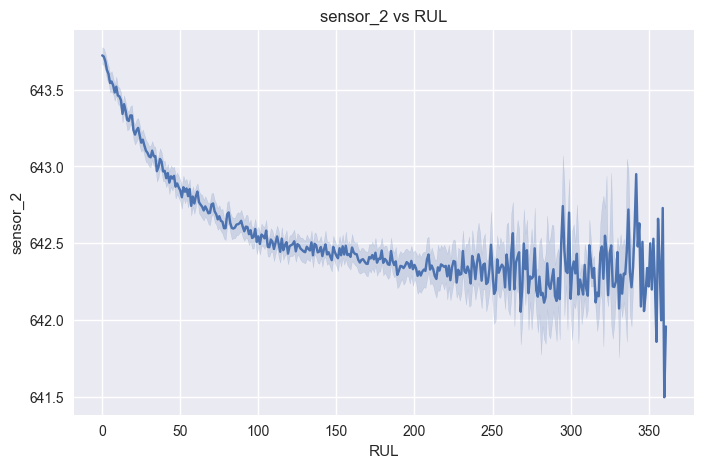

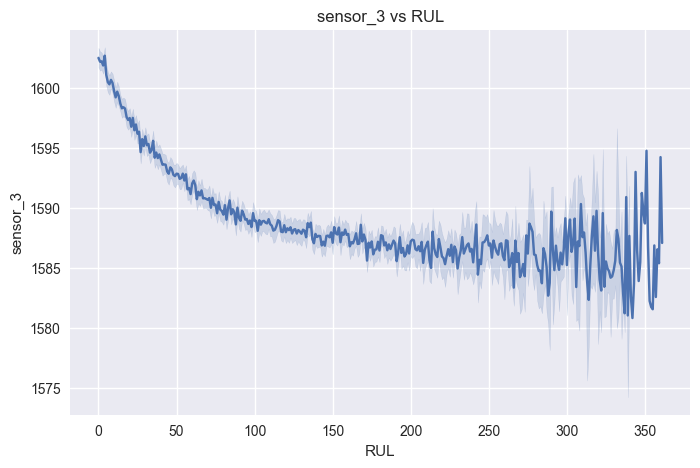

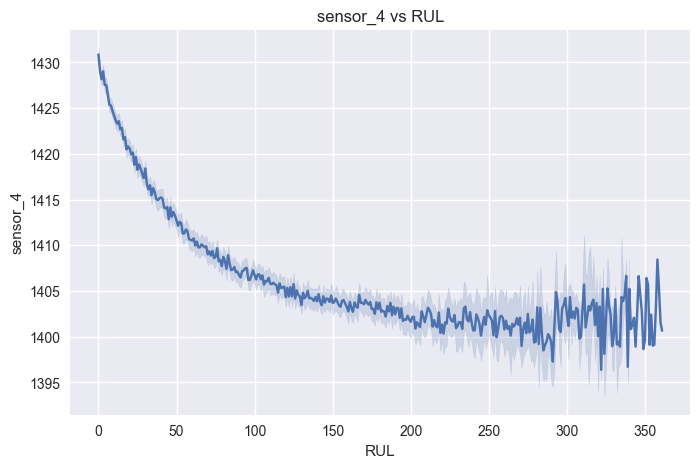

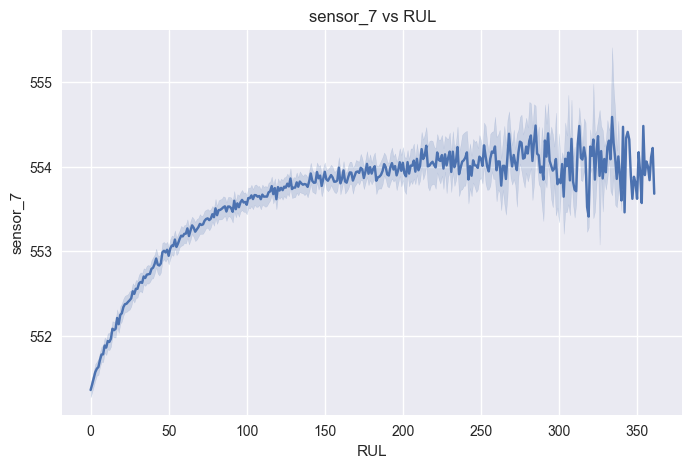

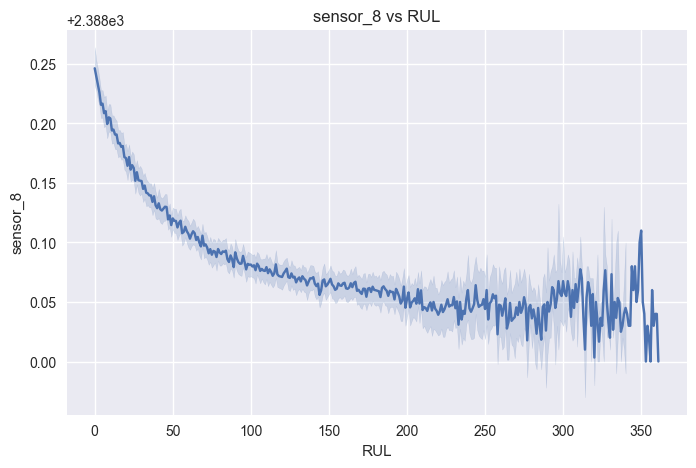

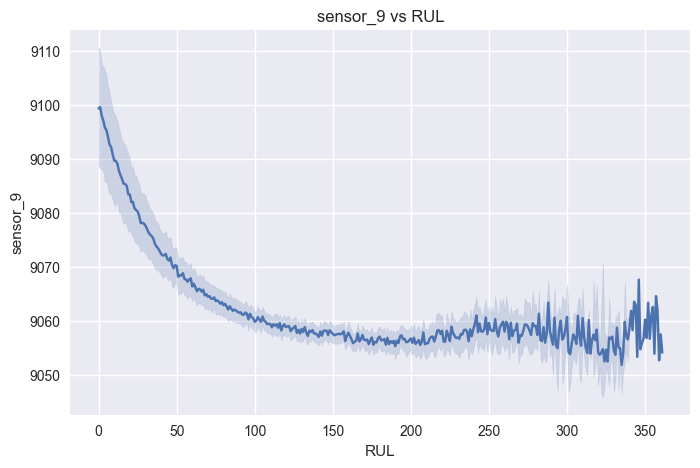

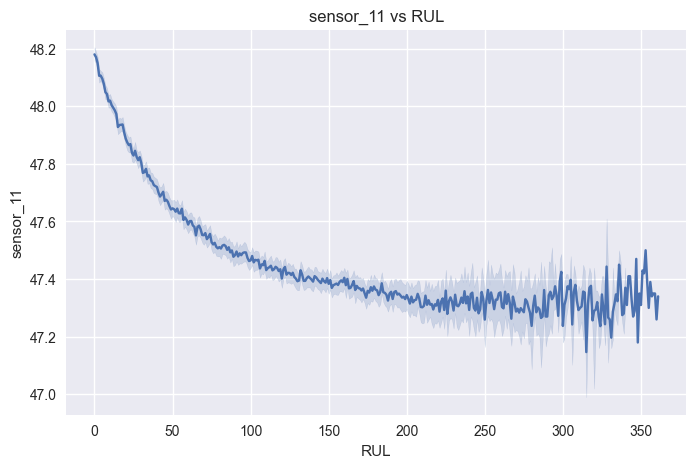

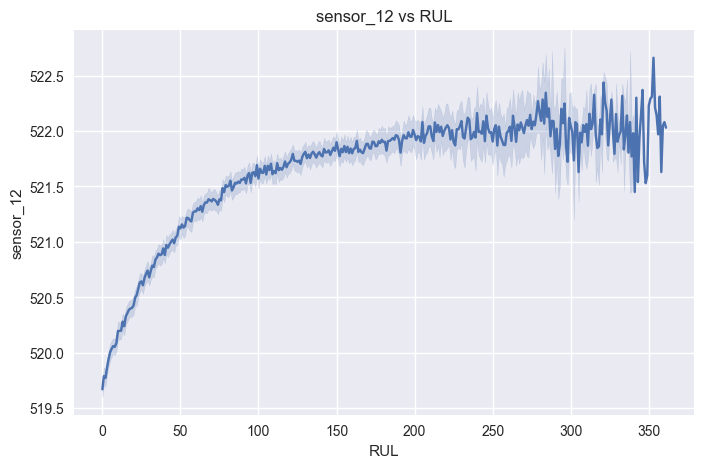

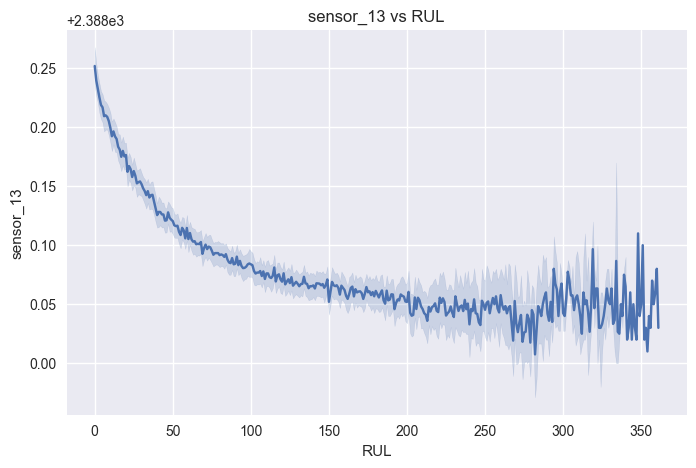

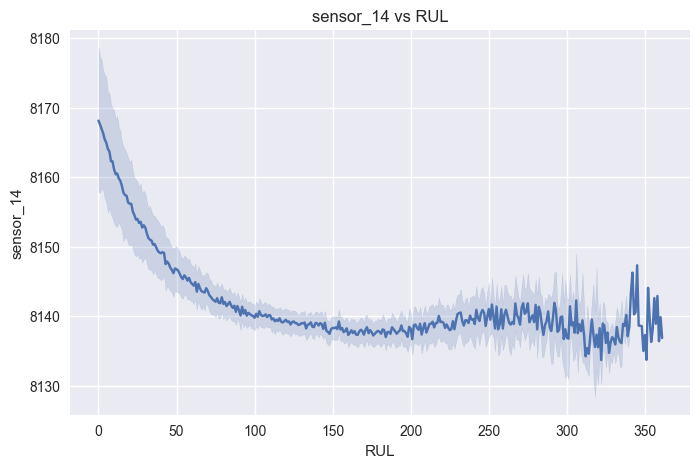

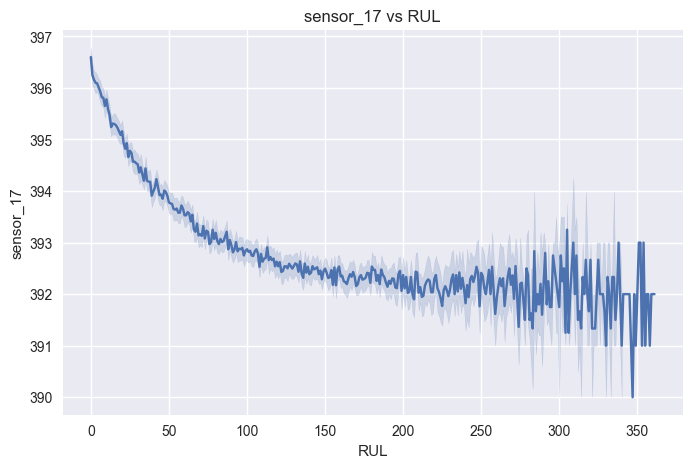

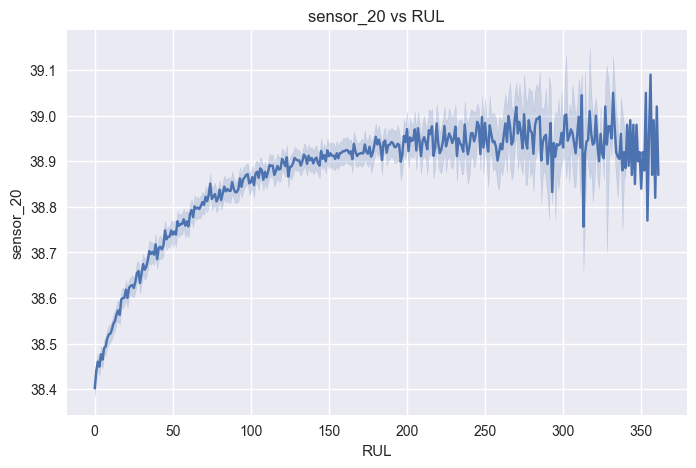

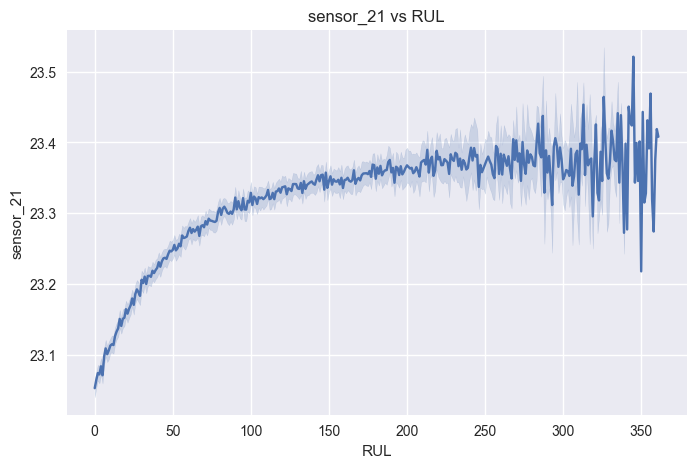

In [17]:
# lets see varition of sensor readings with RUL
# loop through sensor columns and plot lineplot of sensor reading vs RUL
for col in sensor_cols:
    if col in df.columns:  # check if column was not dropped
        plt.figure(figsize=(8,5))
        sns.lineplot(x='RUL', y=col, data=df)
        plt.title(f"{col} vs RUL")
        plt.show()


- no sensor variations at high RUL
- ex. RUL=250 and RUL=300 are both healthy, sensors cant distinguish 
- stable readings -> clip RULs 

### Sensor Behavior Over Time

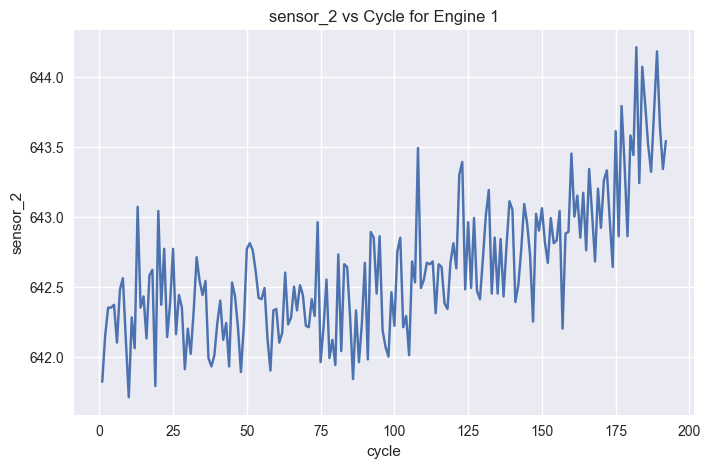

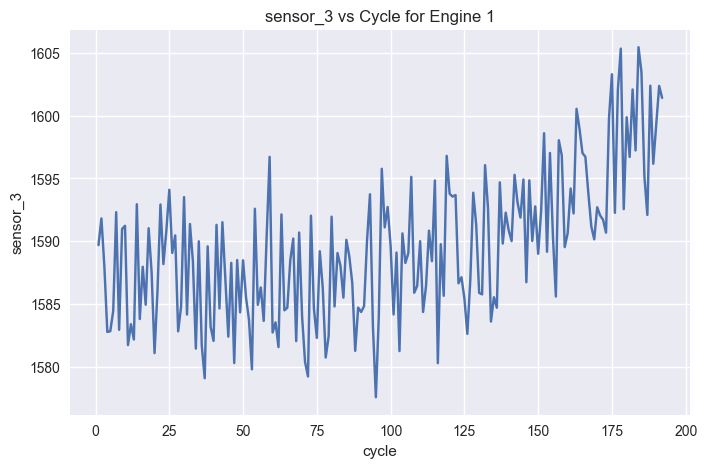

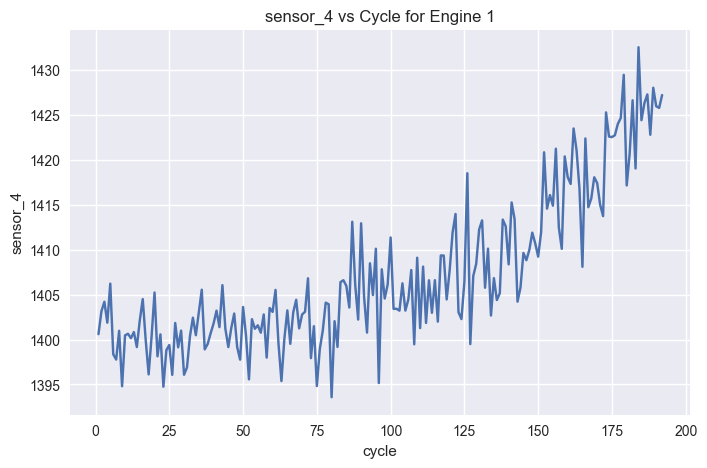

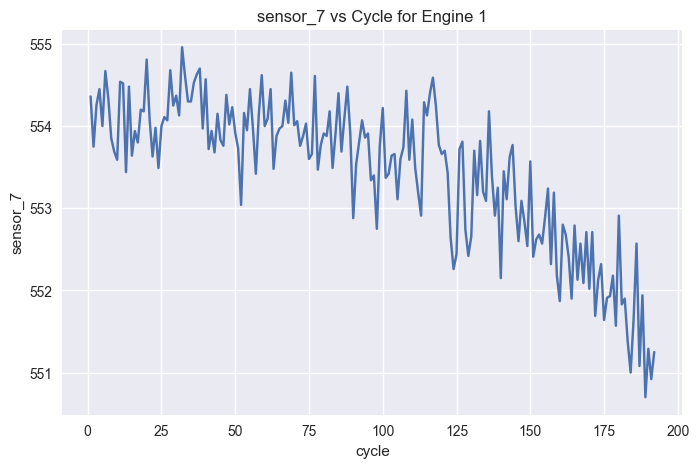

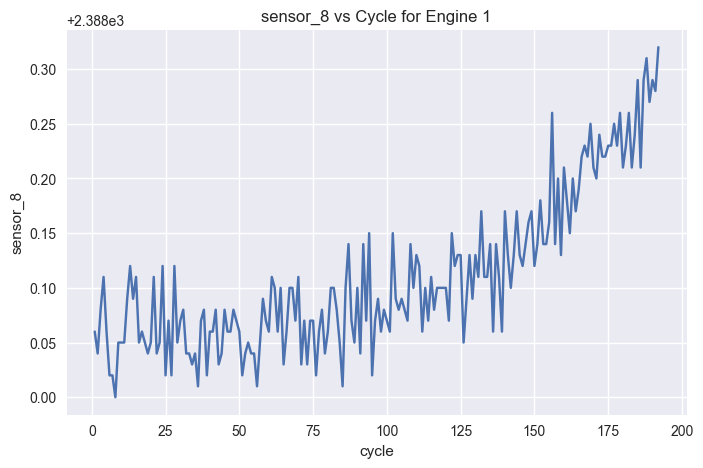

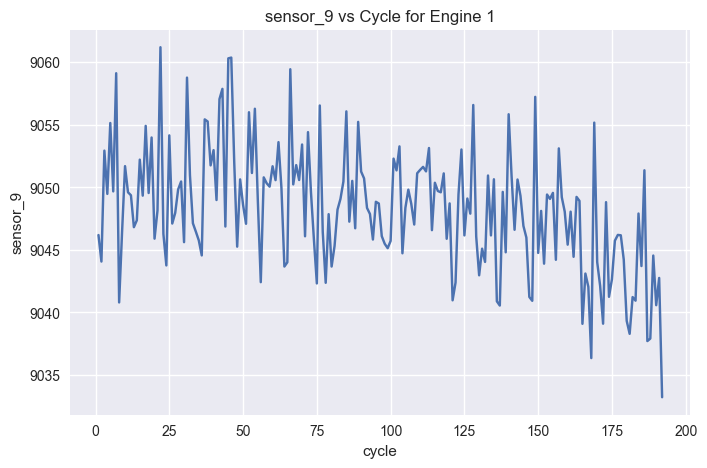

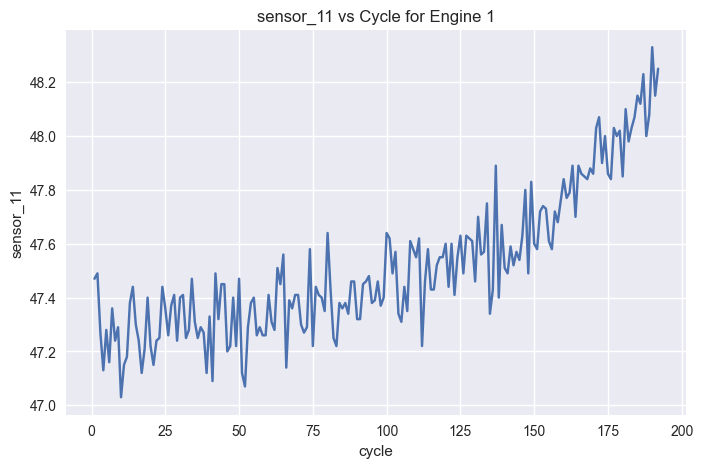

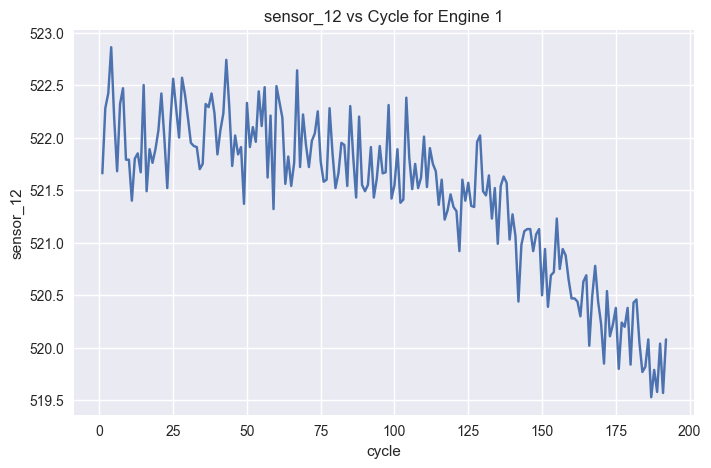

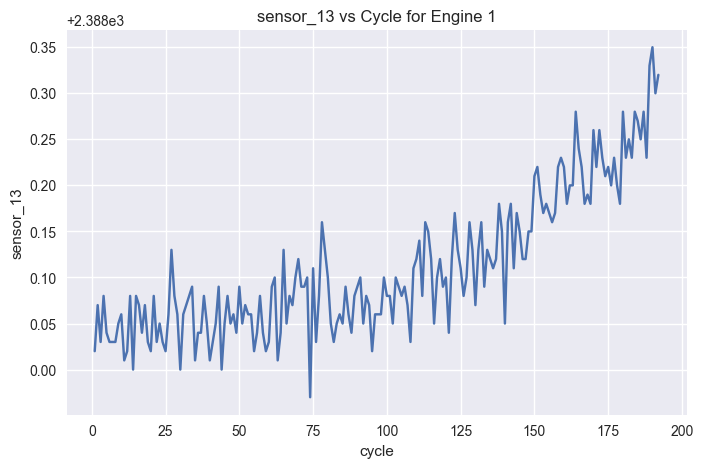

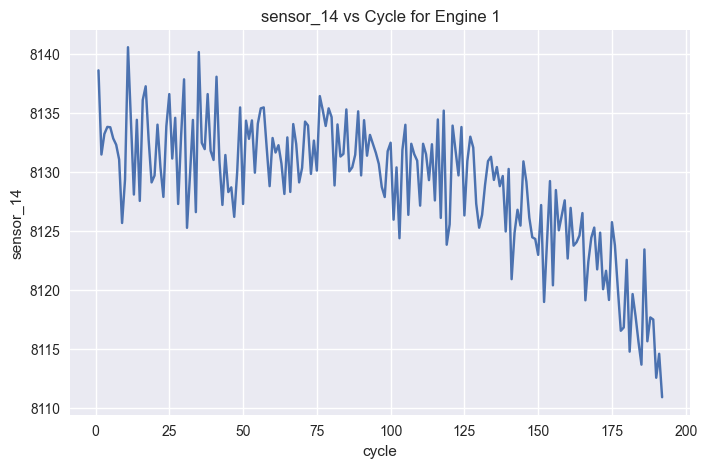

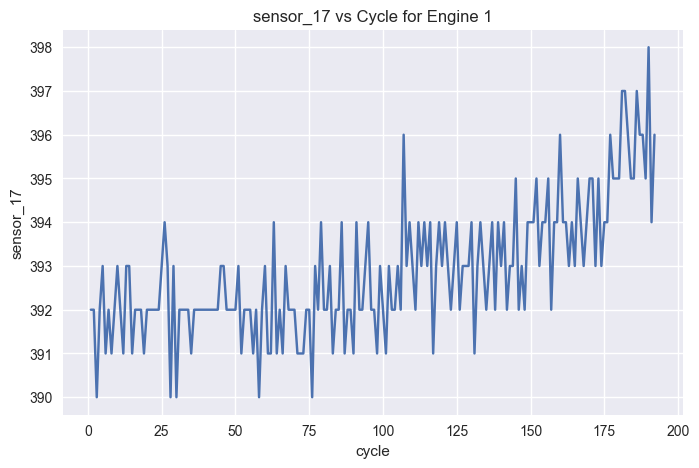

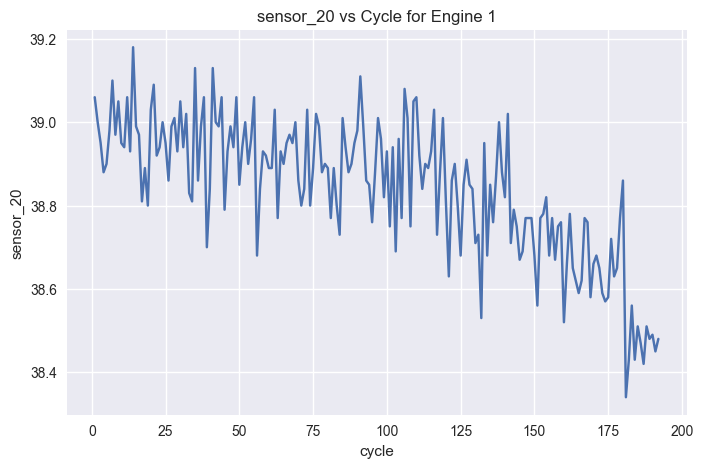

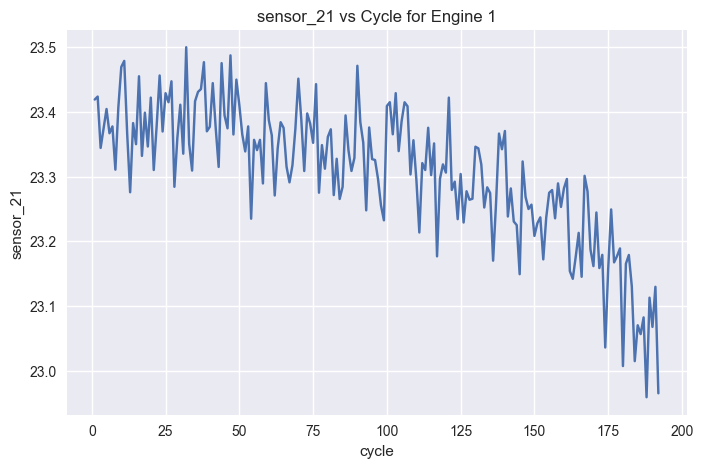

In [18]:
# loop on all sensors for engine 1 and plot lineplot of sensor reading vs cycle
for col in sensor_cols:
    if col in df.columns:  # check if column was not dropped
        plt.figure(figsize=(8,5))
        sns.lineplot(x='cycle', y=col, data=df[df['unit'] == 1])
        plt.title(f"{col} vs Cycle for Engine 1")
        plt.show()

- engine1 sensor shows variations for all time range, as its life time isnt high (below clipping)

In [19]:
# lets try engine with longest lifetime
print(f"Engine with longest lifetime: {max_cycle.idxmax()}, Lifetime: {max_cycle.max()}")

Engine with longest lifetime: 69, Lifetime: 362


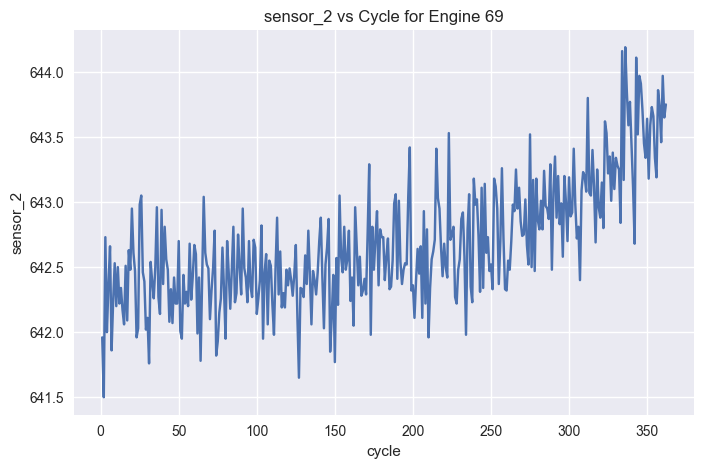

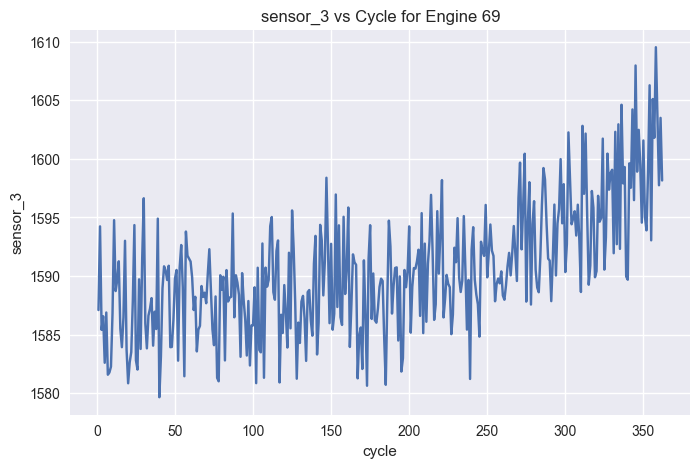

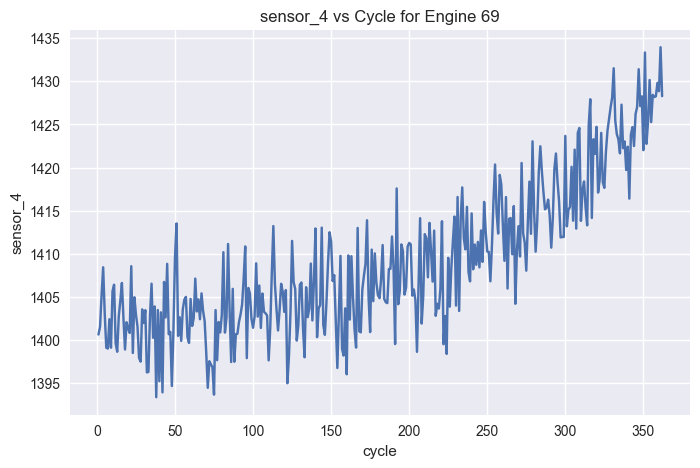

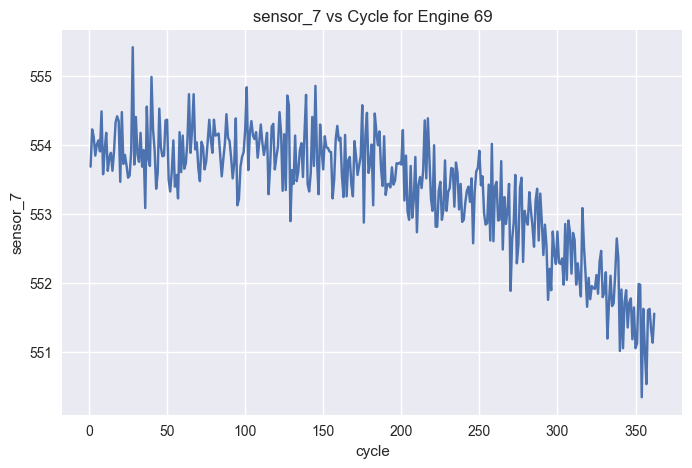

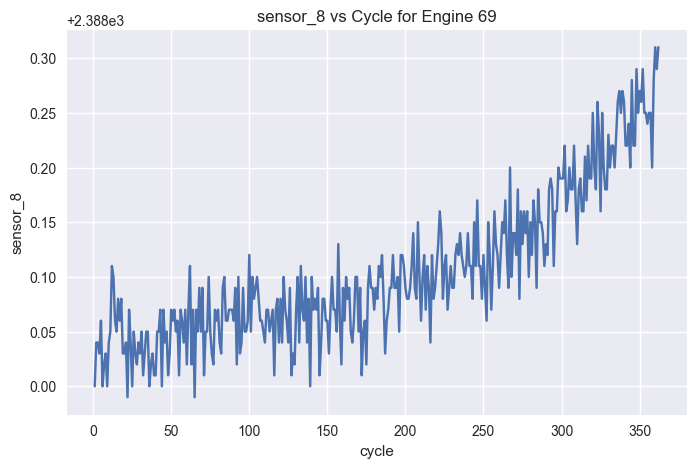

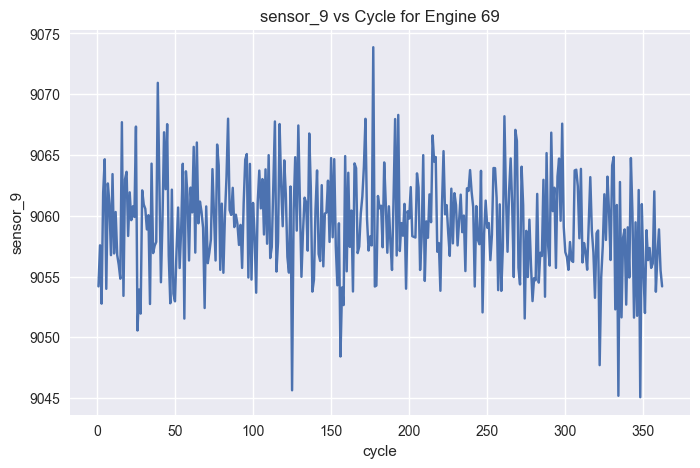

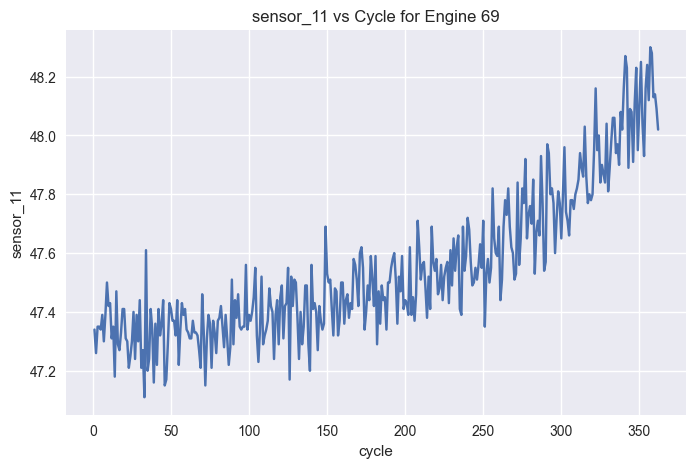

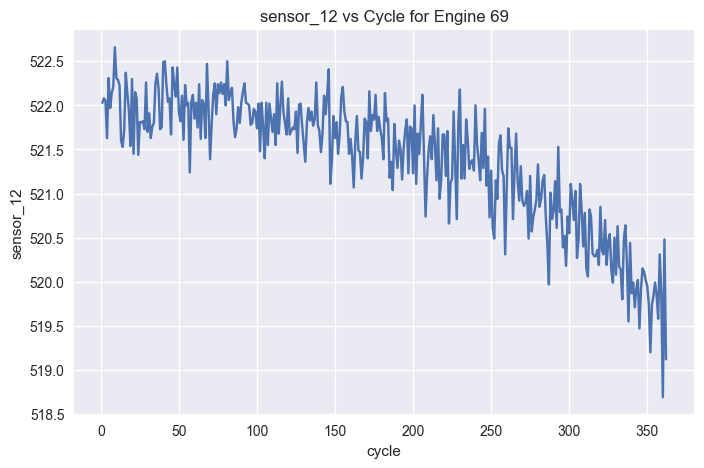

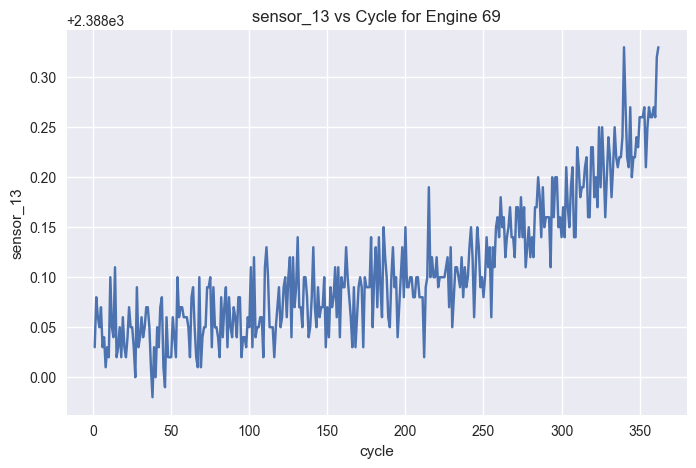

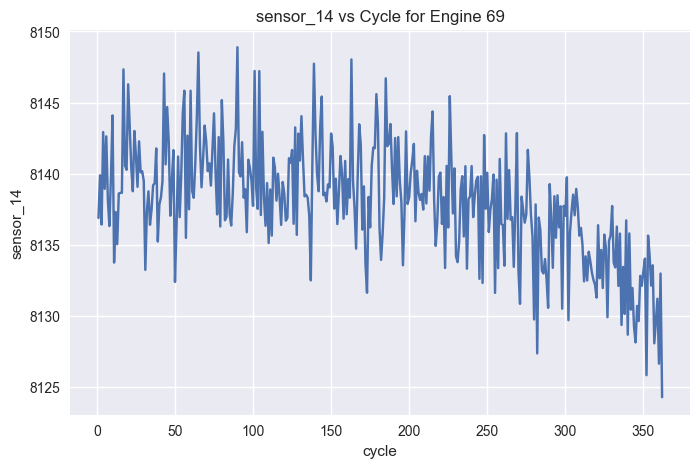

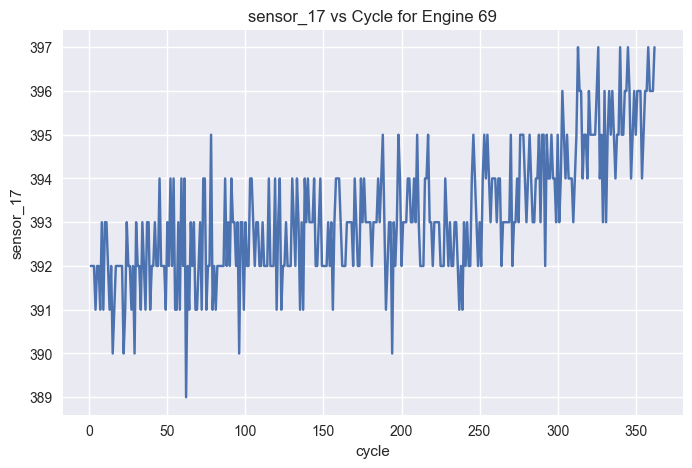

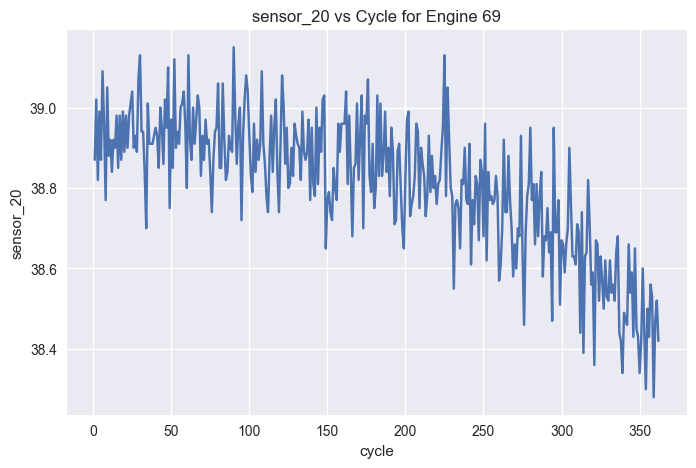

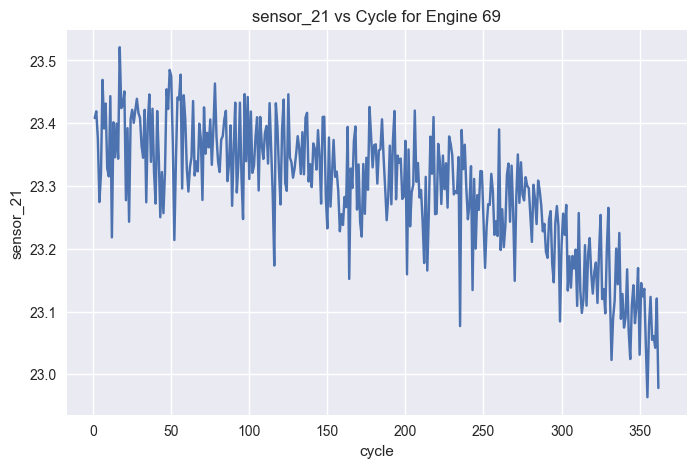

In [20]:
# loop on all sensors for engine 69 and plot lineplot of sensor reading vs cycle
for col in sensor_cols:
    if col in df.columns:  # check if column was not dropped
        plt.figure(figsize=(8,5))
        sns.lineplot(x='cycle', y=col, data=df[df['unit'] == 69])
        plt.title(f"{col} vs Cycle for Engine 69")
        plt.show()

- sensor raedings are stable at the begining (RUL is high)
- we can say readings at cycle 10 (RUL= 362-10 = 352) are mostly the same as reading at cycle 50 (RUL= 362-50 = 312) -> both are healthy 

### `relations between sensors` 

In [21]:
df.columns

Index(['unit', 'cycle', 'op_setting_1', 'op_setting_2', 'op_setting_3',
       'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9',
       'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_17',
       'sensor_20', 'sensor_21', 'RUL'],
      dtype='object')

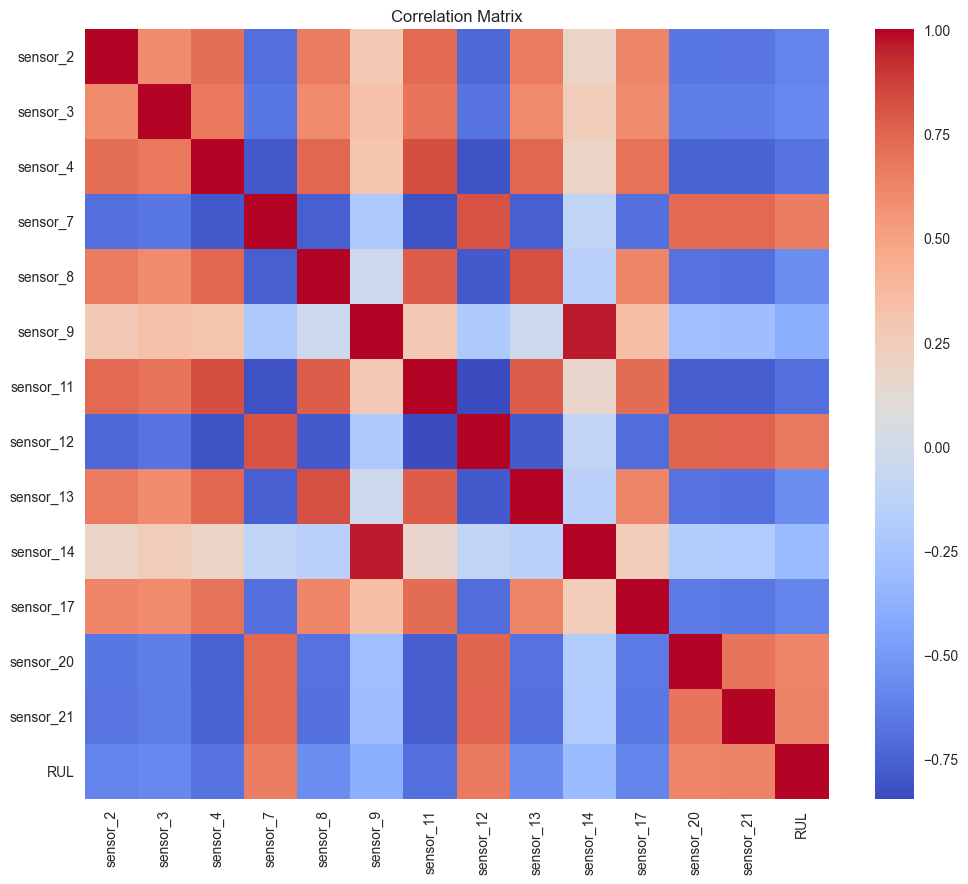

In [22]:
dfreadings = df[sensor_cols + ['RUL']]

plt.figure(figsize=(12,10))
sns.heatmap(dfreadings.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [23]:
# return highly correlated sensor pairs
corr_matrix = dfreadings.corr().abs()
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.8 and corr_matrix.columns[i] != 'RUL' and corr_matrix.columns[j] != 'RUL':
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)
high_corr_pairs

[('sensor_14', 'sensor_9', np.float64(0.9631566003059776)),
 ('sensor_12', 'sensor_11', np.float64(0.8468835930051095)),
 ('sensor_11', 'sensor_4', np.float64(0.8301356963159815)),
 ('sensor_13', 'sensor_8', np.float64(0.8260843322333569)),
 ('sensor_11', 'sensor_7', np.float64(0.8228050249957691)),
 ('sensor_12', 'sensor_4', np.float64(0.815590516105214)),
 ('sensor_12', 'sensor_7', np.float64(0.812712601325414))]

- can drop either sensor_9 or sensor_14

- its prefered to delete highly correlated sensors (redundancy and shared physical phenomena), if working with XGBoost as redundabcy effects its preformace
- no need while using LSTM (Correlation ≠ time behavior)

`important insight`
- The presence of both positively and negatively correlated sensors with RUL suggests that degradation is not monotonic across all features, reinforcing the need for nonlinear models

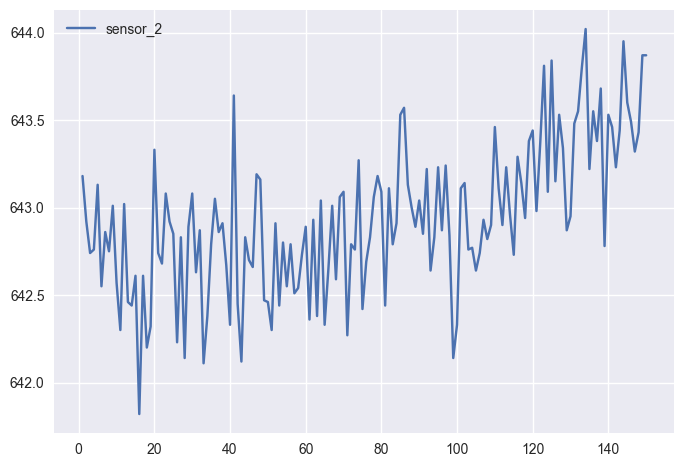

In [24]:
engine_1 = df[df['unit'] == 8]
for sensor in ['sensor_2']:
    plt.plot(engine_1['cycle'], engine_1[sensor], label=sensor)

plt.legend()
plt.show()

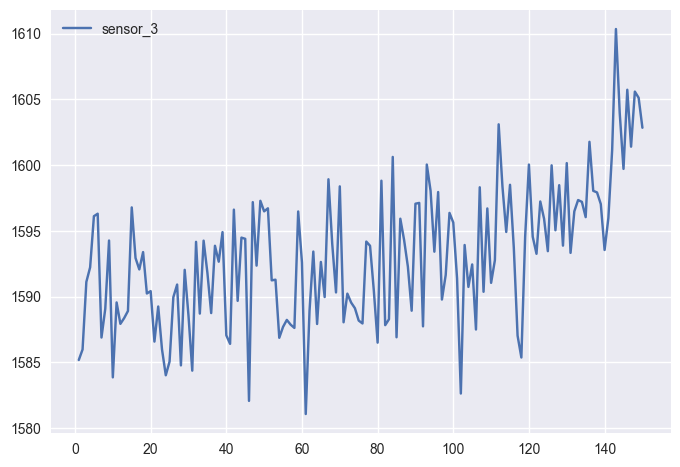

In [25]:
engine_1 = df[df['unit'] == 8]
for sensor in ['sensor_3']:
    plt.plot(engine_1['cycle'], engine_1[sensor], label=sensor)

plt.legend()
plt.show()

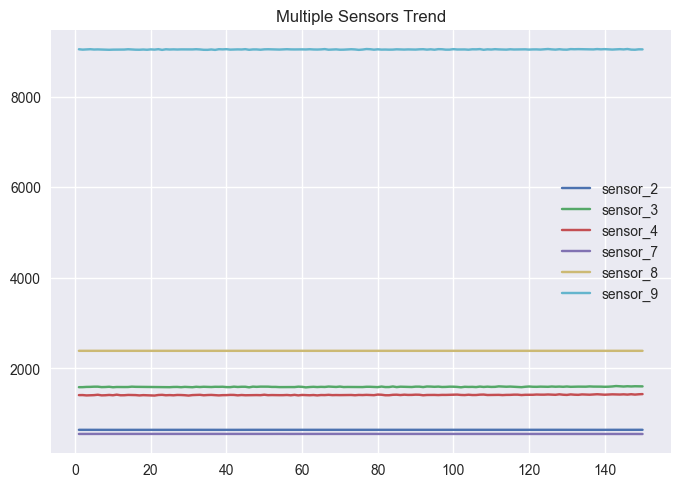

In [26]:
engine_1 = df[df['unit'] == 8]
for sensor in ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9']:
    plt.plot(engine_1['cycle'], engine_1[sensor], label=sensor)

plt.legend()
plt.title("Multiple Sensors Trend")
plt.show()

- sensors have different ranges -> may bias the model later
- standardization required

### Operational Settings

In [27]:
df[['op_setting_1','op_setting_2','op_setting_3']].nunique()

op_setting_1    158
op_setting_2     13
op_setting_3      1
dtype: int64

- op_settings_3 always constant (just ine mode) -> drop

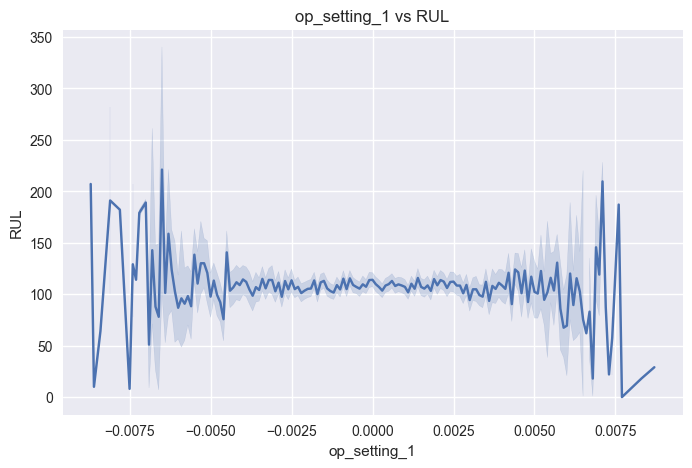

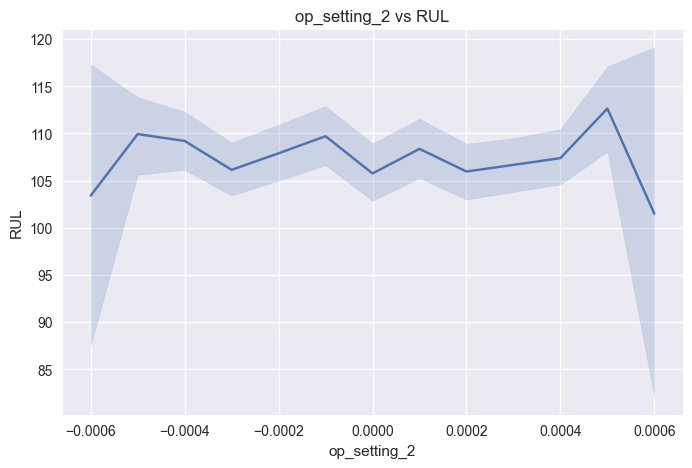

In [28]:
# relationship between other 2 op settings and RUL
for col in ['op_setting_1','op_setting_2']:
    plt.figure(figsize=(8,5))
    sns.lineplot(x=col, y='RUL', data=df)
    plt.title(f"{col} vs RUL")
    plt.show()

- No strong relationship with RUL

- both are noise-like variation, not a degradation driver -> can drop too

## **Preprocessing**

### `Final Feature Selection`
- Drop operational settings (noise)
- Drop low-variance sensor
- Keep informative sensors

In [29]:
feature_cols = [
    'sensor_2', 'sensor_3', 'sensor_4', 'sensor_7',
    'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12',
    'sensor_13', 'sensor_14', 'sensor_17',
    'sensor_20', 'sensor_21'
]

len(feature_cols)


13

In [30]:
train_df = df[['unit', 'cycle'] + feature_cols + ['RUL']].copy()
train_df.head()

,unit,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,392,39.06,23.4190,191.0
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,392,39.00,23.4236,190.0
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,390,38.95,23.3442,189.0
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,392,38.88,23.3739,188.0
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,393,38.90,23.4044,187.0


### `Apply RUL Clipping`

In [31]:
RUL_MAX = 125

train_df['RUL_raw'] = df['RUL']
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_MAX)

- RUL_raw for analysis
- RUL for training (clipped)

In [32]:
train_df[['RUL', 'RUL_raw']].head(10)

,RUL,RUL_raw
0,125.0,191.0
1,125.0,190.0
2,125.0,189.0
3,125.0,188.0
4,125.0,187.0
5,125.0,186.0
6,125.0,185.0
7,125.0,184.0
8,125.0,183.0
9,125.0,182.0


### `Load test set`

In [33]:
test_df = pd.read_csv('../Dataset/test_FD001.txt', sep=' ', header=None)
test_df = test_df.iloc[:, :26]
test_df.columns = ['unit', 'cycle'] + \
                  ['op_setting_1', 'op_setting_2', 'op_setting_3'] + \
                  [f'sensor_{i}' for i in range(1, 22)]

rul_test = pd.read_csv('../Dataset/RUL_FD001.txt', sep=' ', header=None)
rul_test = rul_test.iloc[:, 0]

In [34]:
# compute RUL for test set 
test_max_cycle = test_df.groupby('unit')['cycle'].max()

test_rul_map = {}
for unit in test_df['unit'].unique():
    observed_last = test_max_cycle[unit]
    extra_rul = rul_test.iloc[unit - 1]
    test_rul_map[unit] = observed_last + extra_rul

test_df['RUL'] = test_df.apply(
    lambda row: test_rul_map[row['unit']] - row['cycle'],
    axis=1
)

In [35]:
# Drop unused columns in  train and test

test_df = test_df[['unit', 'cycle'] + feature_cols + ['RUL']]
test_df.head()

,unit,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_20,sensor_21,RUL
0,1,1,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,392,38.86,23.3735,142.0
1,1,2,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,393,39.02,23.3916,141.0
2,1,3,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,393,39.08,23.4166,140.0
3,1,4,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,391,39.00,23.3737,139.0
4,1,5,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,390,38.99,23.4130,138.0


In [36]:
# clip RUL in test as train

test_df['RUL_raw'] = test_df['RUL']
test_df['RUL'] = test_df['RUL'].clip(upper=RUL_MAX)

In [37]:
test_df.head()

,unit,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_17,sensor_20,sensor_21,RUL,RUL_raw
0,1,1,643.02,1585.29,1398.21,553.90,2388.04,9050.17,47.20,521.72,2388.03,8125.55,392,38.86,23.3735,125.0,142.0
1,1,2,641.71,1588.45,1395.42,554.85,2388.01,9054.42,47.50,522.16,2388.06,8139.62,393,39.02,23.3916,125.0,141.0
2,1,3,642.46,1586.94,1401.34,554.11,2388.05,9056.96,47.50,521.97,2388.03,8130.10,393,39.08,23.4166,125.0,140.0
3,1,4,642.44,1584.12,1406.42,554.07,2388.03,9045.29,47.28,521.38,2388.05,8132.90,391,39.00,23.3737,125.0,139.0
4,1,5,642.51,1587.19,1401.92,554.16,2388.01,9044.55,47.31,522.15,2388.03,8129.54,390,38.99,23.4130,125.0,138.0


In [38]:
print(train_df.shape)
print(test_df.shape)

(20631, 17)
(13096, 17)


### `validation split`
- by engine, don't randomly split rows 

In [39]:
units = train_df['unit'].unique()
train_units, val_units = train_test_split(units, test_size=0.15, random_state=42)

train_split_df = train_df[train_df['unit'].isin(train_units)].copy()
val_split_df = train_df[train_df['unit'].isin(val_units)].copy()

In [40]:
train_split_df.shape, val_split_df.shape

((17569, 17), (3062, 17))

### `Normalize features`

- will StandardScaler, since sensor ranges differ

In [41]:
scaler = StandardScaler()

train_split_df[feature_cols] = scaler.fit_transform(train_split_df[feature_cols])
val_split_df[feature_cols] = scaler.transform(val_split_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

- `note:` Don't not fit on test to avoid data leakage

In [42]:
# validate shapes
print(train_split_df.shape, val_split_df.shape, test_df.shape)

(17569, 17) (3062, 17) (13096, 17)


------

## **Sequence creation for LSTM**
- Using sliding windows

`setup`
- window size: 30
- input: sequence of sensor valuse (previous 30 cycles)
- target: RUL at the last time stamp (last cycle of the window)

In [43]:
print(train_split_df.shape)
print(val_split_df.shape)   
print(test_df.shape)

(17569, 17)
(3062, 17)
(13096, 17)


In [44]:
# drop RUL_raw from train and test (no need for modeling)
train_split_df = train_split_df.drop(columns=['RUL_raw'])
val_split_df = val_split_df.drop(columns=['RUL_raw'])
test_df = test_df.drop(columns=['RUL_raw'])

In [45]:
print(train_split_df.shape)
print(val_split_df.shape)
print(test_df.shape)

(17569, 16)
(3062, 16)
(13096, 16)


In [46]:
WINDOW_SIZE = 30

### `Train sequence creation`

generate many windows to give the model many learning examples:  


[cycles 1..30]  -> predict RUL at 30  

[cycles 2..31]  -> predict RUL at 31  

[cycles 3..32]  -> predict RUL at 32  
...

In [47]:
def create_train_sequences(df, feature_cols, window_size=30):
    X, y = [], []

    for unit in df['unit'].unique():
        engine = df[df['unit'] == unit].sort_values('cycle')
        features = engine[feature_cols].values
        targets = engine['RUL'].values

        for i in range(len(engine) - window_size + 1):
            X.append(features[i:i + window_size])
            y.append(targets[i + window_size - 1])

    return np.array(X), np.array(y)

In [48]:
# use it
X_tr, y_tr = create_train_sequences(train_split_df, feature_cols, WINDOW_SIZE)
X_val, y_val = create_train_sequences(val_split_df, feature_cols, WINDOW_SIZE)

print("Train:", X_tr.shape, y_tr.shape)
print("Validation:", X_val.shape, y_val.shape)

Train: (15104, 30, 13) (15104,)
Validation: (2627, 30, 13) (2627,)


- `input(X_train):` 17731 sequence each of length 30 cycle and each cycle contain 13 feature 
- `output(y_train):` RUL at the end of each sequence (at the 30th cycle in the sequence)

### `Test sequence creation`

- Use one sequence per engine

- Take the last 30 cycles from each test engine (where actual failure takes place)

For each engine, you only care about:   

[ last 30 observed cycles ] -> predict RUL at the last observed cycle

In [49]:
def create_test_sequences(df, feature_cols, window_size=30):
    X_test, y_test = [], []

    for unit in df['unit'].unique():
        engine = df[df['unit'] == unit].sort_values('cycle')
        features = engine[feature_cols].values
        target = engine['RUL'].values[-1]

        if len(engine) >= window_size:
            seq = features[-window_size:]
        else:
            pad_len = window_size - len(engine)
            pad = np.repeat(features[:1], pad_len, axis=0)
            seq = np.vstack([pad, features])

        X_test.append(seq)
        y_test.append(target)

    return np.array(X_test), np.array(y_test)

In [50]:
X_test, y_test = create_test_sequences(test_df, feature_cols, WINDOW_SIZE)

print("Test:", X_test.shape, y_test.shape)

Test: (100, 30, 13) (100,)


- `input(X_test):` 1 sequence per engine -> 100 sequence each of 30 cycles(the last 30) and each cycle contain 13 sensor raedings
- `output(y_test):` RUL at the end of sequence (the last observed cycle)

### `Final tensors`

In [51]:
X_tr = torch.tensor(X_tr, dtype=torch.float32)
y_tr = torch.tensor(y_tr, dtype=torch.float32)

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)

X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)


### `Quick Checks`

In [52]:
print(train_df[feature_cols + ['RUL']].isna().sum().sum())
print(test_df[feature_cols + ['RUL']].isna().sum().sum())

0
0


In [53]:
print("Train:", X_tr.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: torch.Size([15104, 30, 13])
Validation: torch.Size([2627, 30, 13])
Test: torch.Size([100, 30, 13])


In [54]:
print(X_tr[0].shape)
print(y_tr[0])

torch.Size([30, 13])
tensor(125.)


### `store final tensors`

In [55]:
# store final tensors
torch.save(X_tr, '../Dataset/FD001/X_train.pt')
torch.save(y_tr, '../Dataset/FD001/y_train.pt')
torch.save(X_val, '../Dataset/FD001/X_val.pt')
torch.save(y_val, '../Dataset/FD001/y_val.pt')
torch.save(X_test, '../Dataset/FD001/X_test.pt')
torch.save(y_test, '../Dataset/FD001/y_test.pt')

### `save scaler`

In [56]:
SAVE_DIR = "../Dataset/FD001"

joblib.dump(scaler, f"{SAVE_DIR}/scaler_fd001.pkl")

['../Dataset/FD001/scaler_fd001.pkl']